# Latent Variable Models (Logistic Regression)

## Emerson Brown gsz5cv

### Foundations of Machine Learning

In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
   - We use these models/functions in analysis because they explain far more realistic information about a model/data. It is hard to capture the true shape of data if you are strictly looking at it linearly. Using these models allows us to see the models nonlinearly, yet still in an interpretable way.
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
   - These cross entropy functions are effective loss functions for fitting logistic regression models because they correspond to finding the maximum likelihood for these outcomes, therefore minimizing the loss. 
3. True or false, and explain: Logistic regression is a linear model.
   - False, logistic regression is not considered a linear model because it does not produce linear predictions compared to the inputs of the function. The regression applies transformations that make it nonlinear. It also does not have the infinite bounds of the linear graph, it must stay between 0 and 1. 
4. True or false, and explain: Logistic regression cannot be used for classification.
   - False, logistic regression can be used for classification but usually in problems using binary values. It is used to classify probabilities through these binary outcomes. 
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
   - No, the change is not in proportion to b in non-linear models. 
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
   - False, feature engineering is still important because although the the model's outputs are nonlinear, it does not mean that you can get rid of feature engineering. You need this because the logistic regression model uses the linear information and features/relationships to capture the logistics. 
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.
    - Overall, true because it is able to tell us more accurate/realistic information regarding the data while involving all of these things intuitively. 

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [234]:
# 2.1 

df = pd.read_csv('./data/data.csv', delimiter = ';')
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [235]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [236]:
df = df.rename(columns={'Tuition fees up to date':'Tuition', 'Scholarship holder': 'Holder', 'Age at enrollment':'Enrollment_age', 'Curricular units 1st sem (approved)' : 'Units_app_1st'})

In [237]:
filtered_cols = ['Debtor', 'Tuition', 'Holder', 'Enrollment_age', 'Units_app_1st', 'Target']
filtered_df = df[filtered_cols]
filtered_df.head()

,Debtor,Tuition,Holder,Enrollment_age,Units_app_1st,Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [238]:
print("Missing values:", filtered_df.isna().sum())

Missing values: Debtor            0
Tuition           0
Holder            0
Enrollment_age    0
Units_app_1st     0
Target            0
dtype: int64


There are no missing values, so I kept working on it as normal. 

In [239]:
filtered_df['target_bi'] = filtered_df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)
filtered_df.head()

C:\Users\emmy4\AppData\Local\Temp\ipykernel_48340\3080624835.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['target_bi'] = filtered_df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)


,Debtor,Tuition,Holder,Enrollment_age,Units_app_1st,Target,target_bi
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


In [240]:
# 2.2
from sklearn.linear_model import LogisticRegression

y = filtered_df['target_bi']
x = filtered_df.drop(['target_bi', 'Target', 'Units_app_1st'], axis=1)

reg = LogisticRegression(penalty=None, max_iter = 5000)
reg = reg.fit(x,y)

pd.DataFrame({'Variable': reg.feature_names_in_, 'Coefficient': reg.coef_[0]})

c:\Users\emmy4\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Debtor,0.527137
1,Tuition,-2.605617
2,Holder,-1.242299
3,Enrollment_age,0.049841


Since positive means more likely and negative means less likely, Debtor and Age of Enrollment predict a higher dropout probability, and Tuition fees up to date and the Scholarship holder predict a lower dropout probability. Being up to date on tuition seems to reduce the dropout risk, since those that are up to date have a less likely probability to dropout.

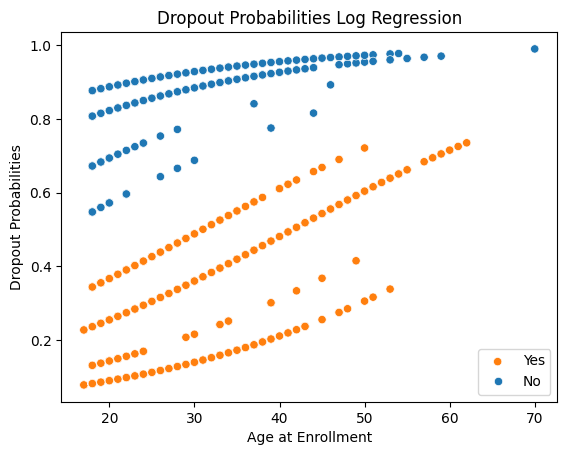

In [241]:
# 2.3

y_reg = reg.predict_proba(x)[:,1]
plot_df = x.copy()
plot_df['dropout_prob'] = y_reg

sns.scatterplot(plot_df, x = 'Enrollment_age', y = 'dropout_prob', hue='Tuition')
plt.title('Dropout Probabilities Log Regression')
plt.xlabel('Age at Enrollment')
plt.ylabel('Dropout Probabilities')
plt.legend(['Yes', 'No'])
plt.show()

I would say that ages of about 40 and under have the most reduced odds of dropping out if they are up to date on their tuition. Overall, I would say that being up to date on your tuition usually helps keep you under about 50% of dropout on average, while not staying up to date puts you above 50% chance usually.

In [242]:
# 2.4

con_mat = pd.crosstab(y, reg.predict(x), rownames=['Actual'], colnames = ['Predicted'])
con_mat

Predicted,0,1
Actual,,
0,2841,162
1,891,530


The prediction for who would not dropout was pretty accurate, but the prediction for who would dropout was not accurate. Of those that did drop out, the model had predicted that more of them would not have than those that did.

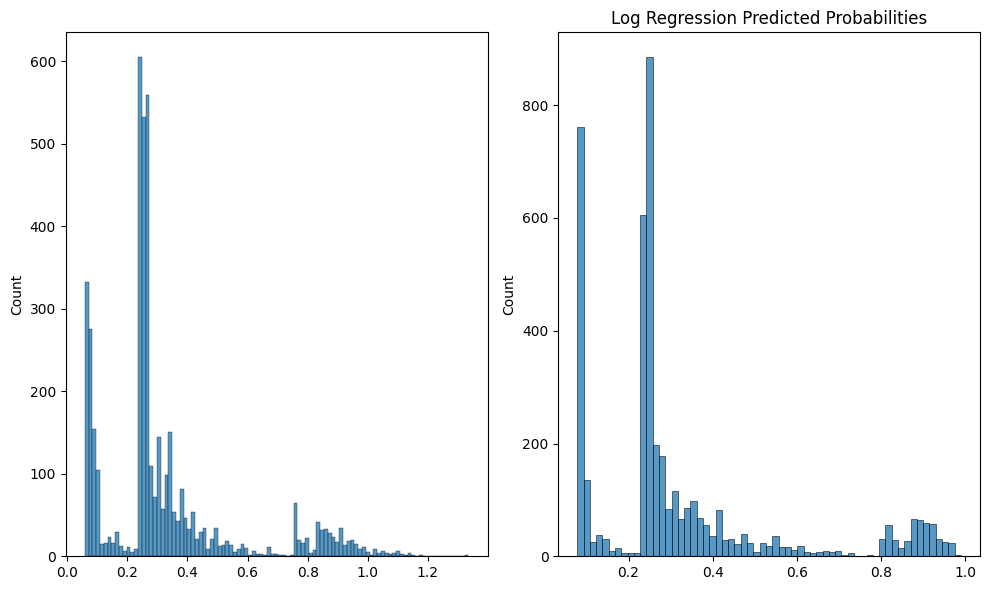

In [243]:
# 2.5

from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin = lin.fit(x,y)
lin_pred = lin.predict(x)

fig, axes = plt.subplots(1, 2, figsize=(10,6))

sns.histplot(lin_pred, ax = axes[0])
plt.title('Linear Model Predicted Probabilities')

sns.histplot(y_reg, ax = axes[1])
plt.title('Log Regression Predicted Probabilities')

plt.tight_layout()
plt.show()


The linear model Predicted a smoother change between the probabilities, while the logistic model shows a rapid declines, then a spike again at around 0.25. 

In [244]:
filtered_df.head()

,Debtor,Tuition,Holder,Enrollment_age,Units_app_1st,Target,target_bi
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0


2.6 

Students that are younger and not up to date on their tuition payments are most at risk of dropping out. I would say that lower interest rates, working more, or providing other financial support or resources for these students to help better manage their money would aid in their financial stress. This would hopefully in turn decrease their chances of dropout. 

In [245]:
# 2.7 

y_mnl = filtered_df['target_bi']
x_mnl = filtered_df.drop(['target_bi', 'Target', 'Holder', 'Enrollment_age'], axis=1)

mnl = LogisticRegression(penalty=None).fit(x_mnl,y_mnl)

mnl_coef = pd.DataFrame(mnl.coef_)
mnl_coef = mnl_coef.set_axis(mnl.feature_names_in_,axis=1)
print('Coefficients for each feature:')
mnl_coef

Coefficients for each feature:


c:\Users\emmy4\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Debtor,Tuition,Units_app_1st
0,0.549744,-2.597398,-0.456609


In [246]:

pd.crosstab( y_mnl, mnl.predict(x_mnl),  rownames=['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,2763,240
1,529,892


The accuracy of this classification is a bit better, but still not great. A significant amount of people are still being falsely classified as dropouts. 

In [247]:

pd.DataFrame(mnl.predict_proba(x_mnl))

,0,1
0,0.315311,0.684689
1,0.346797,0.653203
2,0.033156,0.966844
3,0.876992,0.123008
4,0.818711,0.181289
...,...,...
4419,0.818711,0.181289
4420,0.234532,0.765468
4421,0.918404,0.081596
4422,0.818711,0.181289


My .predict_proba predicted on less value than my hard classification did.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [248]:
# 3.1

df = pd.read_csv('./data/cirrhosis.csv')
df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [249]:
filtered_col = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
filtered_df = df[filtered_col]
filtered_df.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [250]:
filtered_df.isna().sum()

Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

In [251]:
filtered_df = filtered_df.fillna('N/A')
filtered_df

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL
...,...,...,...,...,...
413,1.2,N,N/A,3.0,D
414,0.9,N,N/A,4.0,C
415,1.6,N,N/A,3.0,C
416,0.8,N,N/A,3.0,C


In [252]:
filtered_df['Drug'].value_counts()

# Since there was still a considerable amount of observations that did not have missing values, I did not want to get rid of the 
# values all together. So, I just filled it in with N/A since we do not have that information.

Drug
D-penicillamine    158
Placebo            154
N/A                106
Name: count, dtype: int64

In [253]:
# 3.2 

from sklearn.linear_model import LogisticRegression

filtered_df['Status_bi'] = filtered_df['Status'].apply(lambda x: 1 if x == 'D' else 0)

encoded_df = pd.get_dummies(filtered_df, columns=['Edema', 'Drug'], drop_first=True)

y = encoded_df['Status_bi']
x = encoded_df.drop(['Status', 'Status_bi', 'Stage'], axis=1)

reg = LogisticRegression(penalty=None, max_iter = 5000)
reg = reg.fit(x,y)

pd.DataFrame({'Variable': reg.feature_names_in_, 'Coefficient': reg.coef_[0]})

c:\Users\emmy4\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Bilirubin,0.290337
1,Edema_S,0.953853
2,Edema_Y,2.889584
3,Drug_N/A,-0.405598
4,Drug_Placebo,-0.227630


In [254]:
# 3.3

exp_surv = pd.DataFrame(reg.predict_proba(x))
exp_surv

,0,1
0,0.003073,0.996927
1,0.730678,0.269322
2,0.489280,0.510720
3,0.460328,0.539672
4,0.635972,0.364028
...,...,...
413,0.798127,0.201873
414,0.811798,0.188202
415,0.778767,0.221233
416,0.816193,0.183807


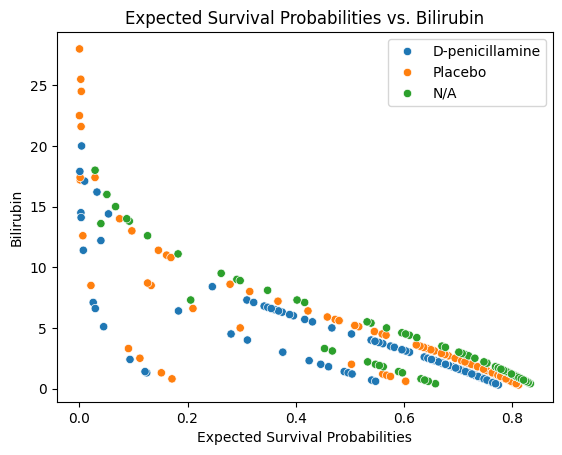

In [255]:
exp_surv = exp_surv.to_numpy()
filtered_df['exp_surv'] = exp_surv[:,0]

sns.scatterplot(data = filtered_df, x = 'exp_surv', y = 'Bilirubin', hue = 'Drug')
plt.title('Expected Survival Probabilities vs. Bilirubin')
plt.xlabel('Expected Survival Probabilities')
plt.ylabel('Bilirubin')
plt.legend()
plt.show()

Low values of Bilirubin, especially as it nears 5 or below, increases the patient's chance of survival drastically. Taking the drug does not make that significant of an impact on survival probability compared to the placebo. 

In [256]:
# 3.4

pd.crosstab( y, reg.predict(x),  rownames=['Actual'], colnames = ['Predicted'])

Predicted,0,1
Actual,,
0,237,20
1,91,70


The accuracy again is not that good. It seems like the accuracy is about 73% or so, which is not horrible, but not great. 

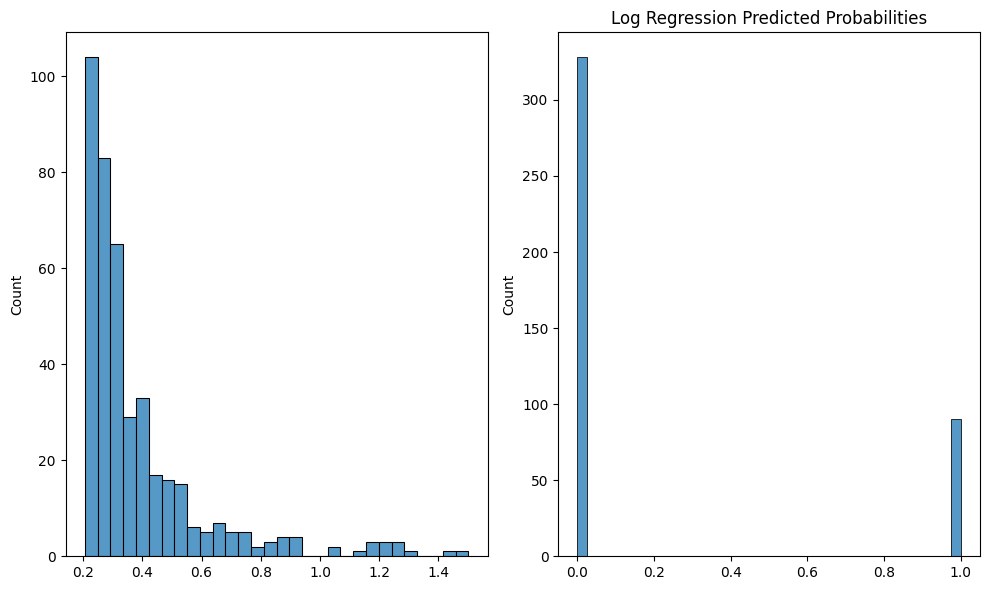

In [257]:
# 3.5 

lin = LinearRegression()
lin = lin.fit(x,y)
lin_pred = lin.predict(x)
log_pred = reg.predict(x)

fig, axes = plt.subplots(1, 2, figsize=(10,6))

sns.histplot(lin_pred, ax = axes[0])
plt.title('Linear Model Predicted Probabilities')

sns.histplot(log_pred, ax = axes[1])
plt.title('Log Regression Predicted Probabilities')

plt.tight_layout()
plt.show()

My linear model showed a gradual decline, with a fairly obvious shape. My logistic regression on the other hand did not predict probabilities well and just predicted whether they would survive or not, not the probabilities. 

In [258]:
encoded_df['Stage'].unique()

array([4.0, 3.0, 2.0, 1.0, 'N/A'], dtype=object)

In [259]:
# 3.6 

encoded_df = encoded_df[encoded_df['Stage'] != 'N/A']
encoded_df['Stage'] = encoded_df['Stage'].astype(int)

# encoded_df = pd.get_dummies(filtered_df, columns=['Edema', 'Drug'], drop_first=True)

y = encoded_df['Stage']
x = encoded_df[['Edema_S', 'Edema_Y', 'Bilirubin']]

reg = LogisticRegression(penalty=None, max_iter = 5000)
reg = reg.fit(x,y)

pd.DataFrame({'Variable': reg.feature_names_in_, 'Coefficient': reg.coef_[0]})

pd.crosstab( y, reg.predict(x),  rownames=['Actual'], colnames = ['Predicted'])

c:\Users\emmy4\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Predicted,3,4
Actual,,
1,20,1
2,82,10
3,131,24
4,94,50


In [260]:

log_prob = pd.DataFrame(reg.predict_proba(x))
log_prob

,0,1,2,3
0,0.000002,0.033462,0.120340,0.846196
1,0.070528,0.256852,0.397748,0.274872
2,0.031138,0.129319,0.340600,0.498943
3,0.027513,0.127390,0.338995,0.506102
4,0.036223,0.246524,0.405062,0.312191
...,...,...,...,...
407,0.068557,0.256556,0.398314,0.276572
408,0.074626,0.257392,0.396535,0.271447
409,0.061170,0.255209,0.400327,0.283294
410,0.076755,0.257635,0.395888,0.269722


My hard classification predicts for stages 3 and 4, while my second did all classes and all values

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

![Local Image](IMG_8392.png "Latent Variable Models HW Question 4")